# This is a test run for MLP

## Group 12

In [ ]:
# import relevant libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import time
from typing import Tuple, List, Dict, Optional, Any
torch.manual_seed(42)
# Reproducibility
np.random.seed(42)
# check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# verify Pytorch and CUDA versions
cuda_version = torch.version.cuda
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {cuda_version}")


PyTorch version: 2.10.0+cu128
CUDA version: 12.8


# Get the CIFAR-10 dataset

In [ ]:
# get the cifar-10 dataset
print("\nLOADING CIFAR-10 DATA")
# set seed for reproducibility
torch.manual_seed(42)
SEED=42
# apply transformations to the data
transform_2 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

cifar_train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_2)
cifar_test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_2)
#print(f"Training samples: {len(cifar_train_data)}")
#print(f"Test samples: {len(cifar_test_data)}")

# split the training data into train and validation sets
val_size_cf = 10000
gen=torch.Generator().manual_seed(SEED)
train_size_cf = len(cifar_train_data) - val_size_cf
train_ds_cf, val_ds_cf = random_split(cifar_train_data, [train_size_cf, val_size_cf], gen)

# Create CIFAR DataLoaders

train_loader_cf = DataLoader(train_ds_cf, batch_size=64, shuffle=True)
val_loader_cf = DataLoader(val_ds_cf, batch_size=128, shuffle=False)
test_loader_cf = DataLoader(cifar_test_data, batch_size=256, shuffle=False)

# print to see the length of the datasets
print("\n===DIMENSIONS OF THE CIFAR DATA===")
print(f"Total Training samples: {len(cifar_train_data)}")
print(f"Total test samples: {len(cifar_test_data)}")

# print to see the length of the datasets
print("\n=== CIFAR DIMENSIONS AFTER SPLIT===")
print(f" CIFAR Training samples: train_ds_cf = {len(train_ds_cf)}")
print(f" CIFAR Validation samples: val_ds_cf = {len(val_ds_cf)}")
print(f" CIFAR Test samples: test_data = {len(cifar_test_data)}")



LOADING CIFAR-10 DATA


100%|██████████| 170M/170M [00:05<00:00, 30.8MB/s]



===DIMENSIONS OF THE CIFAR DATA===
Total Training samples: 50000
Total test samples: 10000

=== CIFAR DIMENSIONS AFTER SPLIT===
 CIFAR Training samples: train_ds_cf = 40000
 CIFAR Validation samples: val_ds_cf = 10000
 CIFAR Test samples: test_data = 10000


# Get the FashionMNIST dataset

In [ ]:
# 1. Load Fashion-MNIST data

# set seedf
SEED=42
torch.manual_seed(42)
print("\n1. LOADING FASHION-MNIST DATA")
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)


# split the training data into train and validation sets
val_size = 10000
gen = torch.Generator().manual_seed(SEED) # gen is needed for consistency
train_size = len(train_dataset) - val_size
train_ds, val_ds = random_split(train_dataset, [train_size, val_size], gen)

# Create DataLoaders

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# print to see the length of the datasets
print("\n\n===DIMENSIONS OF THE FASHION-MNIST DATA===")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(test_dataset)}")

# print to see the length of the datasets
print("\n===DIMENSIONS AFTER SPLIT===")
print(f"Training samples: train_ds = {len(train_ds)}")
print(f"Validation samples: val_ds = {len(val_ds)}")
print(f"Test samples: test_dataset = {len(test_dataset)}")


1. LOADING FASHION-MNIST DATA


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.4MB/s]



===DIMENSIONS OF THE FASHION-MNIST DATA===
Training samples: 60000
Validation samples: 10000

===DIMENSIONS AFTER SPLIT===
Training samples: train_ds = 50000
Validation samples: val_ds = 10000
Test samples: test_dataset = 10000


In [ ]:
# return the text labels
#def text_labels(self, indices):
#    """Return text labels."""
#    labels_indices = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
#              'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
#    return [labels[int(i)] for i in label_indices]

#instance(data, fashion_mnist)

for images, labels in train_loader:
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break

Image batch dimensions: torch.Size([64, 1, 28, 28])
Image label dimensions: torch.Size([64])


The Fashion-MNIST consists of images from 10 categories, each represented by 6000 images in the training dataset and by 1000 in the test dataset.The training set and the test set contain 60,000 and 10,000 images, respectively.

check out page 4.2 in the book

# Build the model

In [ ]:
class BaselineMLP(nn.Module):
    """
    Baseline MLP to use as baseline. This is implemented
    using 2 layers (input and output) and a hidden layer with ReLU activation function
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        output_dim: int,
        activation: str = 'relu'
    ):
        super().__init__()

        self.activation_name = activation

        # Build layers
        dims = [input_dim] + hidden_dims + [output_dim]

        # From before: nn.ModuleList to store layers
        self.layers = nn.ModuleList()

        print(f"\n[MLP Architecture] Building network: {dims}")

        for i in range(len(dims) - 1):
            layer = nn.Linear(dims[i], dims[i+1])
            self.layers.append(layer)
            print(f"  Layer {i}: Linear({dims[i]} → {dims[i+1]})")

        # Activation function
        self.activation = self._get_activation(activation)


    def _get_activation(self, name: str):
        """Get activation function by name."""
        activations = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
            'leaky_relu': nn.LeakyReLU(0.1),
            'elu': nn.ELU()
        }
        return activations.get(name, nn.ReLU())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward method. Since MLP is linear, we need to flatten the image
        before passing into the layers.
        Note that each operation creates a node in the computation graph
        """
        # Flatten image data for MLP
        if x.dim() > 2:
            x = x.view(x.size(0), -1)

        # Pass through layers
        for i, layer in enumerate(self.layers):
            # Linear transformation
            x = layer(x)

            # Check gradient function
            #if x.requires_grad and x.grad_fn is not None:
            #    print(f"  After layer {i}: grad_fn = {x.grad_fn}")

            # Apply activation (except last layer)
            if i < len(self.layers) - 1:
                x = self.activation(x)

        return x

#BaselineMLP(784, [128, 128], 10) # this is for unit testing


# train the model
def model_training(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 40, # Reduced epochs for faster demo
    learning_rate: float = 0.001,
    monitor_interval: int = 5
):
    """
    Train model. Watch how gradients behave during training
    """

    # The Loss for classification
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # History tracking
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        #'gradient_norms': {name: [] for name, _ in model.named_parameters()},
    }

    print(f"\n=== Training: {type(model).__name__} ===")

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss, total_correct, total_samples = 0, 0, 0

        for batch_X, batch_y in train_loader:
            # Move data batch to the selected device. The model and data
            # must be on the same device to perform operations.
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_X.size(0)
            total_correct += (predictions.argmax(dim=1) == batch_y).sum().item()
            total_samples += batch_X.size(0)

        # Record training metrics
        avg_train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)

        # Validation
        model.eval()
        total_val_loss, total_val_correct, total_val_samples = 0, 0, 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                # Move validation data to the device.
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)

                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                total_val_loss += loss.item() * batch_X.size(0)
                total_val_correct += (predictions.argmax(dim=1) == batch_y).sum().item()
                total_val_samples += batch_X.size(0)

        # Record validation metrics
        avg_val_loss = total_val_loss / total_val_samples
        val_acc = total_val_correct / total_val_samples
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        # Detailed monitoring
        if epoch % monitor_interval == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d}: "
                  f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2%}, | "
                  f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2%}")

    return history


def compare_architectures(train_loader: DataLoader, val_loader: DataLoader):
    """
    Compare different models: MLP architectures vs a deeper model when available.
    This is a placeholder. Will leverage this later.
    """
    print("\n" + "="*80)
    print("MLP ARCHITECTURES PERFORMANCE ON FASHION-MNIST")
    print("="*80)

    INPUT_DIM = 28* 28  # Fashion-MNIST image height and width size
    OUTPUT_DIM = 10     # 10 classes

    architectures = {
        'Baseline (2 layers)': BaselineMLP(
            input_dim=INPUT_DIM,
            hidden_dims=[128], # can be two. A reasonably sized shallow network
            output_dim=OUTPUT_DIM
        )
    }

    results = {}

    for name, model in architectures.items():
        # Move the entire model to the selected device (GPU or CPU).
        # This operation moves all of the model's parameters and buffers.
        model.to(device)

        history = model_training(
            model, train_loader, val_loader,
            epochs=40, # 20 epochs is enough to see the trend
            learning_rate=0.001
        )

        results[name] = {
            'model': model,
            'history': history,
            'final_train_acc': history['train_acc'][-1],
            'final_val_acc': history['val_acc'][-1]
        }
    return results


# create viuals
def visualize_training_results(results: Dict[str, Dict]):
    """
    Comprehensive visualization of training results.
    """
    plt.style.use('seaborn-v0_8-darkgrid')

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle('MLP Architecture on Fashion-MNIST', fontsize=16)

    # 1. Training Loss curves
    ax = axes[0, 0]
    for name, data in results.items():
        history = data['history']
        ax.plot(history['train_loss'], '--', label=f'{name} (train)', alpha=0.7)
        ax.plot(history['val_loss'], '-', label=f'{name} (val)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Training Curves (Loss)'); ax.legend(); ax.grid(True, alpha=0.3)

    # 2. Training Accuracy curves
    ax = axes[0, 1]
    for name, data in results.items():
        history = data['history']
        ax.plot(history['train_acc'], '--', label=f'{name} (train)', alpha=0.7)
        ax.plot(history['val_acc'], '-', label=f'{name} (val)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_title('Training Curves (Accuracy)'); ax.legend(); ax.grid(True, alpha=0.3)

    # 3. Final performance comparison
    ax = axes[1, 0]
    names = list(results.keys())
    val_accs = [results[n]['final_val_acc'] * 100 for n in names]

    bars = ax.bar(names, val_accs, alpha=0.8)
    ax.set_ylabel('Final Validation Accuracy (%)')
    ax.set_title('Final Performance')
    ax.set_xticklabels(names, rotation=25, ha='right')
    ax.set_ylim(bottom=max(0, min(val_accs) - 10))
    ax.bar_label(bars, fmt='%.1f%%')
    ax.grid(True, alpha=0.3, axis='y')




MLP PERFORMANCE ON FASHION-MNIST

1. LOADING FASHION-MNIST DATA

===DIMENSIONS OF THE FASHION-MNIST DATA===
Training samples: 60000
Validation samples: 10000

===DIMENSIONS AFTER SPLIT===
Training samples: train_ds = 55000
Validation samples: val_ds = 5000
Test samples: test_dataset = 10000

MLP ARCHITECTURES PERFORMANCE ON FASHION-MNIST

[MLP Architecture] Building network: [784, 128, 10]
  Layer 0: Linear(784 → 128)
  Layer 1: Linear(128 → 10)

=== Training: BaselineMLP ===
Epoch   0: Train Loss: 0.5546, Train Acc: 80.66%, | Val Loss: 0.4673, Val Acc: 84.42%
Epoch   5: Train Loss: 0.2973, Train Acc: 89.19%, | Val Loss: 0.3314, Val Acc: 87.64%
Epoch  10: Train Loss: 0.2455, Train Acc: 90.91%, | Val Loss: 0.3177, Val Acc: 88.62%
Epoch  15: Train Loss: 0.2100, Train Acc: 92.17%, | Val Loss: 0.3336, Val Acc: 88.22%
Epoch  20: Train Loss: 0.1838, Train Acc: 93.11%, | Val Loss: 0.3324, Val Acc: 88.76%
Epoch  25: Train Loss: 0.1627, Train Acc: 94.02%, | Val Loss: 0.3354, Val Acc: 89.26%
Epo

/tmp/ipython-input-1621010248.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=25, ha='right')


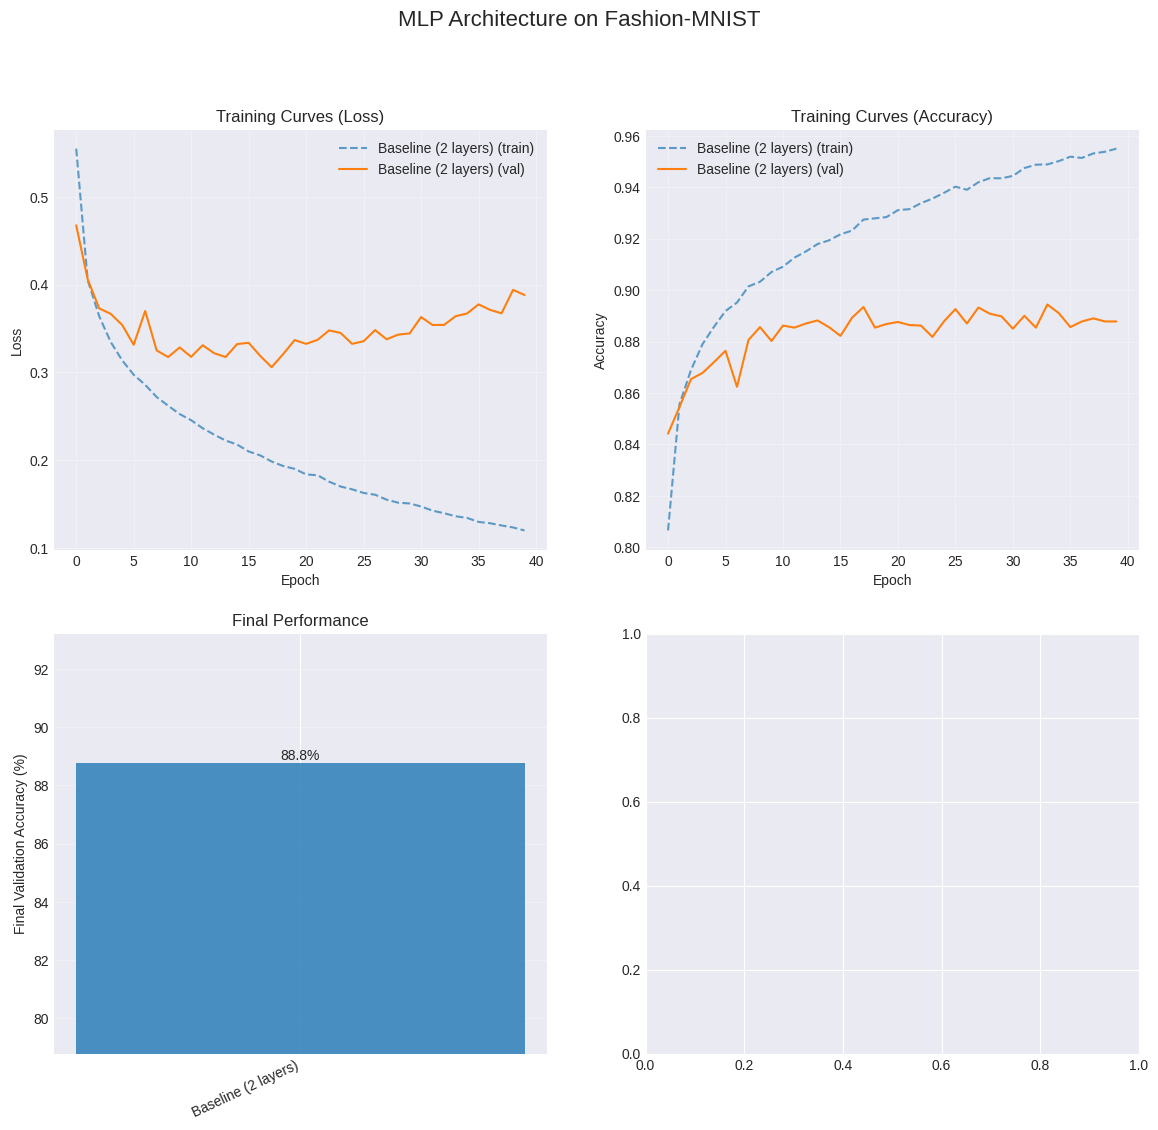

In [ ]:
# get some results

def main():
    """
    Complete demonstration of MLPs on the FashionMNIST dataset.
    """
    print("="*80)
    print("MLP PERFORMANCE ON FASHION-MNIST")
    print("="*80)

    # 1. Load Fashion-MNIST data
    # set seed
    torch.manual_seed(42)
    print("\n1. LOADING FASHION-MNIST DATA")
    transform = transforms.Compose([transforms.ToTensor()])

    train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    # split the training data into train and validation sets
    val_size = 5000
    train_size = len(train_dataset) - val_size
    train_ds, val_ds = random_split(train_dataset, [train_size, val_size])

    # Create DataLoaders

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

    # print to see the length of the datasets
    print("\n===DIMENSIONS OF THE FASHION-MNIST DATA===")
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(test_dataset)}")

    # print to see the length of the datasets
    print("\n===DIMENSIONS AFTER SPLIT===")
    print(f"Training samples: train_ds = {len(train_ds)}")
    print(f"Validation samples: val_ds = {len(val_ds)}")
    print(f"Test samples: test_dataset = {len(test_dataset)}")


    # 2. Architecture comparison
    results = compare_architectures(train_loader, val_loader)

    # 3. Visualize results
    visualize_training_results(results)




if __name__ == "__main__":
    main()